### Лабораторная работа №3
#### Ковалев А.В. ИУ5-63Б
1. Импорт библиотек.

In [127]:
import numpy as np
import pandas as pd
"""import seaborn as sns
import matplotlib.pyplot as plt"""
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, cross_validate, LeaveOneOut
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import matplotlib.pyplot as plt
"""
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
%matplotlib inline 
sns.set(style="ticks")"""

'\nfrom sklearn.impute import SimpleImputer\nfrom sklearn.impute import MissingIndicator\nfrom sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer\n%matplotlib inline \nsns.set(style="ticks")'

2. Загрузка и первичный анализ аднных

In [128]:
cars = pd.read_csv('Automobile_data.csv', sep=",")
print('Кол-во строк: ', cars.shape[0],'\n' ,'Кол-во столбцов: ', cars.shape[1], sep = '')
print(cars.dtypes)
print('Пропуски по столбцам:', cars.isnull().sum())
cars.head(8)

Кол-во строк: 205
Кол-во столбцов: 26
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object
Пропуски по столбцам: symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheel

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920


3. Выбор необходимых столбцов

In [129]:
#cars_nec = cars["body-style","wheel_base", "width", "height", "curbe_weight", "engine_type", "num-of-cylinders", "bore", "fuel_system", "engine-size", "horse_power"]
cars_nec = cars[["body-style","wheel-base", "width", "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size", "horsepower"]]

4. Кодирование категориальных признаков

In [130]:
def encode(frame:pd.DataFrame, col_name:str, type: str, maps: dict) -> pd.DataFrame:
    res_frame = frame.copy()
    if type != "label" and type != "map":
        raise AssertionError
    elif type == "label":
        cat_enc = pd.DataFrame({'c':frame[col_name]})
        le = LabelEncoder()
        cat_enc_le = le.fit_transform(cat_enc['c'])
        count_arr = [i for i in range(0, len(cat_enc['c'].unique()))]
        print(le.inverse_transform(count_arr))
        print(np.unique(cat_enc_le))
        res_frame[col_name] = cat_enc_le
    else:
        print(maps)
        res_frame[col_name] = cars_nec[col_name].map(maps)
    return res_frame
cols_of_cats = [("body-style", "label", {}), ("engine-type", "label", {}),  ("num-of-cylinders", "map", {'two':2, "three": 3, "four": 4, "five": 5, "six":6, "eight": 9, "twelve": 12})]
for col in cols_of_cats:
    cars_nec = encode(cars_nec, col[0],col[1], col[2] )
cars_nec.head(8)

['convertible' 'hardtop' 'hatchback' 'sedan' 'wagon']
[0 1 2 3 4]
['dohc' 'dohcv' 'l' 'ohc' 'ohcf' 'ohcv' 'rotor']
[0 1 2 3 4 5 6]
{'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 9, 'twelve': 12}


,body-style,wheel-base,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,horsepower
0,0,88.6,64.1,48.8,2548,0,4,130,111
1,0,88.6,64.1,48.8,2548,0,4,130,111
2,2,94.5,65.5,52.4,2823,5,6,152,154
3,3,99.8,66.2,54.3,2337,3,4,109,102
4,3,99.4,66.4,54.3,2824,3,5,136,115
5,3,99.8,66.3,53.1,2507,3,5,136,110
6,3,105.8,71.4,55.7,2844,3,5,136,110
7,4,105.8,71.4,55.7,2954,3,5,136,110


5. С помощью train_test_split делим выборку на обучающую и тестовую

In [131]:
body_X_train, body_X_test, body_y_train, body_y_test = train_test_split(
    cars[["wheel-base", "width", "height", "curb-weight"]], cars["body-style"], test_size=0.2, random_state=1)
print(body_X_train, body_X_test, body_y_train, body_y_test, sep="\n")
cl1_1 = KNeighborsClassifier(n_neighbors=50)
cl1_1.fit(body_X_train, body_y_train)
target1_0 = cl1_1.predict(body_X_train)
target1_1 = cl1_1.predict(body_X_test)
accuracy_score(body_y_train, target1_0), accuracy_score(body_y_test, target1_1)

     wheel-base  width  height  curb-weight
106        99.2   67.9    49.7         3139
90         94.5   63.8    54.5         2017
147        97.0   65.4    53.0         2455
185        97.3   65.5    55.7         2212
95         94.5   63.8    53.3         2028
..          ...    ...     ...          ...
133        99.1   66.5    56.1         2695
137        99.1   66.5    56.1         2847
72         96.6   70.5    50.8         3685
140        93.3   63.8    55.7         2240
37         96.5   65.2    53.3         2236

[164 rows x 4 columns]
     wheel-base  width  height  curb-weight
78         93.7   64.4    50.8         2004
97         94.5   63.8    53.5         2037
151        95.7   63.6    54.5         2040
44         94.5   63.6    52.0         1874
40         96.5   62.5    54.1         2372
67        110.0   70.3    56.5         3515
98         95.1   63.8    53.3         2008
18         88.4   60.3    53.2         1488
152        95.7   63.6    54.5         2015
62      

(0.4817073170731707, 0.4146341463414634)

In [132]:
scores = cross_val_score(KNeighborsClassifier(n_neighbors=50), 
                         cars[["wheel-base", "width", "height", "curb-weight"]], cars["body-style"], 
                         cv=LeaveOneOut())
scores, np.mean(scores)

(array([0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1.,
        1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1.,
        1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1.,
        0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.,
        0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
        0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1.,
        0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1.,
        1., 1., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1.,
        1.]),
 np.float64(0.47804878048780486))

In [133]:
n_range = np.array(range(5,55,5))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=LeaveOneOut(), scoring='accuracy')
clf_gs.fit(cars[["wheel-base", "width", "height", "curb-weight"]], cars["body-style"])
clf_gs.best_params_

{'n_neighbors': np.int64(35)}

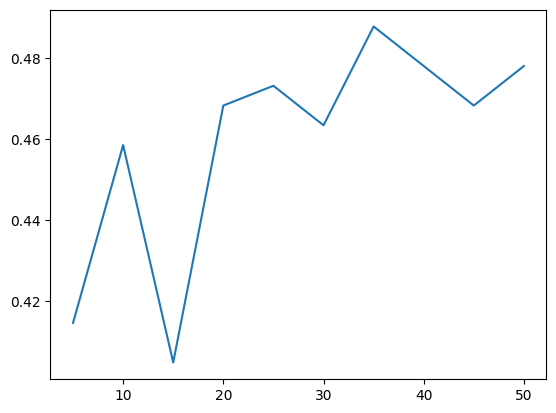

In [134]:
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])
